In [1]:
%load_ext autoreload
%autoreload 2

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

from utils import set_seed
set_seed(42)

from agents import SmartGridAgent

 Random seed зафиксирован: 42


# Вспомогательные функции времени

In [2]:
def get_season(month):
    """Возвращает сезон по номеру месяца"""
    if month in [12, 1, 2]: return 'winter'
    elif month in [3, 4, 5]: return 'spring'
    elif month in [6, 7, 8]: return 'summer'
    else: return 'autumn'
    
def get_holiday_type_2025_fixed(timestamp):
    """Определяет тип дня для 2025 года с учетом праздников"""
    month = timestamp.month
    day = timestamp.day
    weekday = timestamp.weekday()
    
    if month == 12 and day == 31: return 'new_year_eve'
    if month == 1 and day == 1: return 'new_year_morning'
    if month == 1 and day == 2: return 'holiday_day_1_2'
    if month == 1 and day in [3, 4, 5, 6, 7, 8]: return 'holiday_day_3_8'
    if month == 5 and day in [1, 2, 3, 4]: return 'may_holiday_1_4'
    if month == 5 and day in [5, 6, 7]: return 'may_working_week'
    if month == 5 and day in [8, 9, 10, 11]: return 'may_holiday_8_11'
    if (month == 2 and day == 23) or (month == 3 and day == 8) or \
       (month == 6 and day == 12) or (month == 11 and day == 4):
        return 'other_holiday'
    if (month == 2 and day == 22) or (month == 3 and day == 7) or \
       (month == 4 and day == 30) or (month == 5 and day == 7) or \
       (month == 6 and day == 11) or (month == 11 and day == 3):
        return 'shortened_day'
    if weekday >= 5: return 'weekend'
    
    return 'weekday'

# Запуск агентов и сборка dataframe

In [3]:


grid = SmartGridAgent(num_residential=60, num_commercial=80, num_industrial=1)

start_date = pd.Timestamp("2025-01-01")
end_date = pd.Timestamp("2025-12-31 23:00:00")
date_range = pd.date_range(start=start_date, end=end_date, freq='h') # Используем 'h' вместо 'H' для новых версий pandas



for i, timestamp in enumerate(date_range):
    day_type = get_holiday_type_2025_fixed(timestamp)
    season = get_season(timestamp.month)
    
    # Делаем один шаг симуляции
    grid.step(timestamp, day_type, season)
    


# 3. Сборка итогового DataFrame
df_final = pd.DataFrame({
    'timestamp': grid.timestamp_history,
    'consumption': grid.get_total_consumption(),
    'day_type': [get_holiday_type_2025_fixed(ts) for ts in grid.timestamp_history],
    'season': [get_season(ts.month) for ts in grid.timestamp_history]
})

print(f"Итоговый размер данных: {df_final.shape}")
df_final.head()

Итоговый размер данных: (8760, 4)


,timestamp,consumption,day_type,season
0,2025-01-01 00:00:00,2.146565e+06,new_year_morning,winter
1,2025-01-01 01:00:00,2.119573e+06,new_year_morning,winter
2,2025-01-01 02:00:00,2.152983e+06,new_year_morning,winter
3,2025-01-01 03:00:00,2.190193e+06,new_year_morning,winter
4,2025-01-01 04:00:00,2.115497e+06,new_year_morning,winter


# Подготовка данных для графиков

In [4]:

df_final['hour'] = df_final['timestamp'].dt.hour
df_final['weekday'] = df_final['timestamp'].dt.weekday

y_final = df_final['consumption'].values



# Детализация первой недели и профили дней

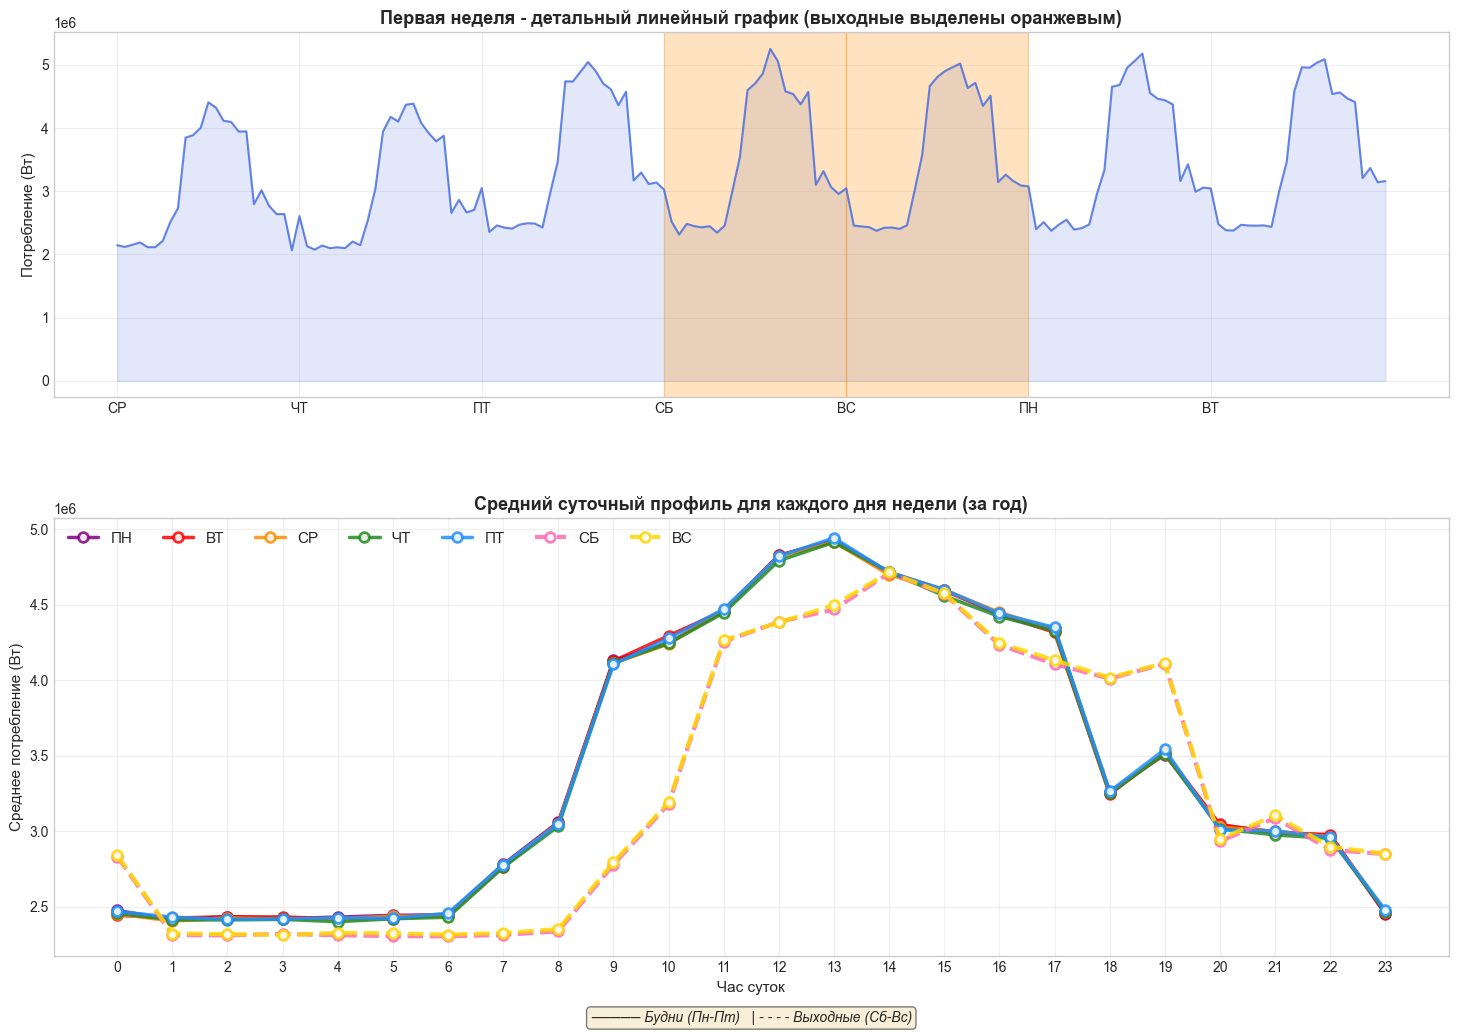

In [5]:


fig = plt.figure(figsize=(18, 12)) 
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1.2], hspace=0.3)

first_week_start = 0 * 24
first_week_end = 7 * 24
first_week_data = y_final[first_week_start:first_week_end]
first_week_hours = np.arange(len(first_week_data))

# График 1: Детальный вид первой недели с выделением выходных 
ax1 = fig.add_subplot(gs[0])
ax1.plot(first_week_hours, first_week_data, linewidth=1.5, color='royalblue', alpha=0.8)
ax1.fill_between(first_week_hours, first_week_data, alpha=0.15, color='royalblue')
ax1.set_title('Первая неделя - детальный линейный график (выходные выделены оранжевым)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Потребление (Вт)', fontsize=11)
ax1.set_xticks(range(0, 168, 24))
ax1.set_xticklabels(['СР', 'ЧТ', 'ПТ', 'СБ', 'ВС', 'ПН', 'ВТ'], fontsize=10)
ax1.grid(True, alpha=0.3)

for day_idx in range(7):
    if day_idx in [3, 4]: # СБ и ВС для первой недели 2025
        start_h = day_idx * 24
        end_h = (day_idx + 1) * 24
        ax1.axvspan(start_h, end_h, alpha=0.25, color='darkorange')




# График 2: Средний профиль для каждого дня недели 
ax2 = fig.add_subplot(gs[1])
colors_unique = ['purple', 'red', 'darkorange', 'forestgreen', 'dodgerblue', 'hotpink', 'gold']
weekday_full_names_short = ['ПН', 'ВТ', 'СР', 'ЧТ', 'ПТ', 'СБ', 'ВС']

for day_of_week in range(7):
    hourly_vals = df_final[df_final['weekday'] == day_of_week].groupby('hour')['consumption'].mean().values
    color = colors_unique[day_of_week]
    linestyle = '--' if day_of_week >= 5 else '-'
    linewidth = 3 if day_of_week >= 5 else 2.5
    label = weekday_full_names_short[day_of_week]
    
    ax2.plot(range(24), hourly_vals, marker='o', linewidth=linewidth, markersize=7,
            color=color, label=label, alpha=0.85, linestyle=linestyle,
            markerfacecolor='white', markeredgewidth=2)

ax2.set_title('Средний суточный профиль для каждого дня недели (за год)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Час суток', fontsize=11)
ax2.set_ylabel('Среднее потребление (Вт)', fontsize=11)
ax2.set_xticks(range(0, 24, 1))
ax2.legend(fontsize=11, ncol=7, loc='upper left', framealpha=0.95, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3)

legend_text = '───── Будни (Пн-Пт)   | - - - - Выходные (Сб-Вс)'
ax2.text(0.5, -0.15, legend_text, transform=ax2.transAxes, fontsize=10,
        ha='center', style='italic', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.savefig('data/01_week_analysis.png', dpi=150, bbox_inches='tight')

# Детализация сезонов и года


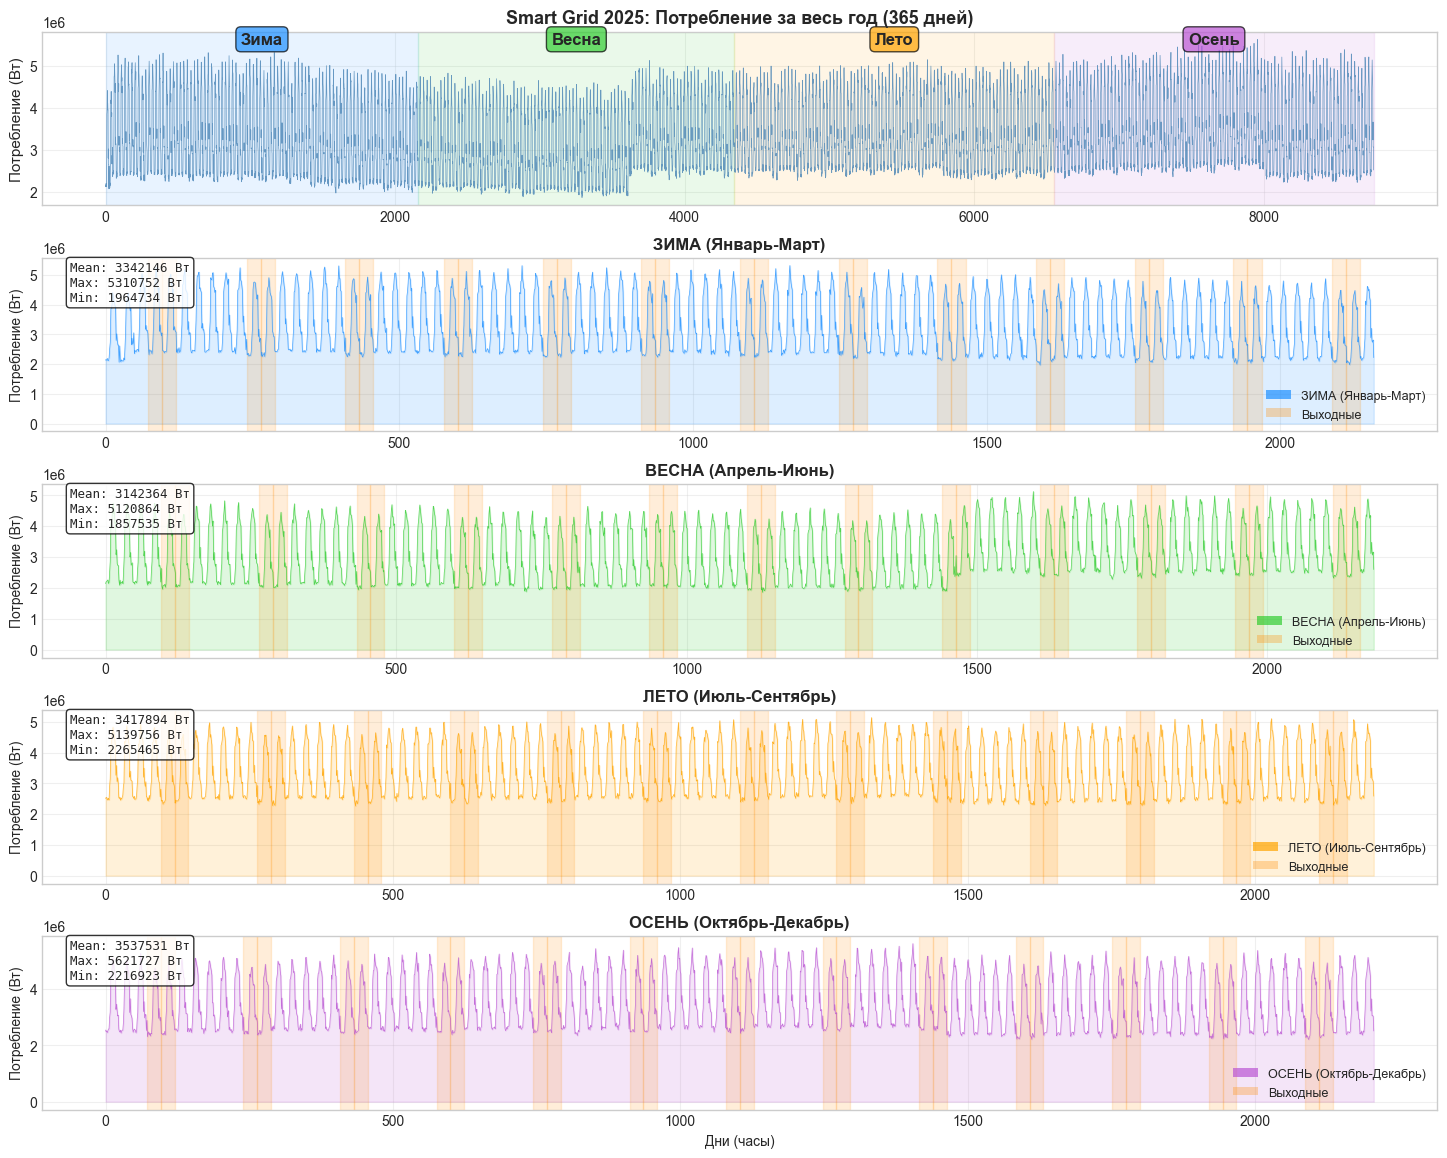

In [6]:

hours_array = np.arange(len(y_final))

fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 1, 1], hspace=0.3)

#  График 1: Полный год 
ax = fig.add_subplot(gs[0])
ax.plot(hours_array, y_final, linewidth=0.5, color='steelblue', alpha=0.8)
ax.set_title('Smart Grid 2025: Потребление за весь год (365 дней)', fontsize=13, fontweight='bold')
ax.set_ylabel('Потребление (Вт)', fontsize=11)
ax.grid(True, alpha=0.3)

seasons_full = [
    (0, 90, 'Зима', 'dodgerblue'),
    (90, 181, 'Весна', 'limegreen'),
    (181, 273, 'Лето', 'orange'),
    (273, 365, 'Осень', 'mediumorchid'),
]

for start_day, end_day, season_name, color in seasons_full:
    start_hour = start_day * 24
    end_hour = end_day * 24
    ax.axvspan(start_hour, end_hour, alpha=0.1, color=color)
    mid_hour = (start_hour + end_hour) / 2
    ax.text(mid_hour, ax.get_ylim()[1]*0.95, season_name, 
           fontsize=12, ha='center', fontweight='bold',
           bbox=dict(boxstyle='round', facecolor=color, alpha=0.7))

# Графики 2-5: Отдельные сезоны 
season_data_list = [
    {'name': 'ЗИМА (Январь-Март)', 'start': 0, 'end': 90, 'color': 'dodgerblue'},
    {'name': 'ВЕСНА (Апрель-Июнь)', 'start': 90, 'end': 181, 'color': 'limegreen'},
    {'name': 'ЛЕТО (Июль-Сентябрь)', 'start': 181, 'end': 273, 'color': 'orange'},
    {'name': 'ОСЕНЬ (Октябрь-Декабрь)', 'start': 273, 'end': 365, 'color': 'mediumorchid'},
]

for idx, season_dict in enumerate(season_data_list):
    ax = fig.add_subplot(gs[idx + 1])
    start_hour = season_dict['start'] * 24
    end_hour = season_dict['end'] * 24
    season_data = y_final[start_hour:end_hour]
    season_hours = np.arange(len(season_data))
    color = season_dict['color']
    
    ax.plot(season_hours, season_data, linewidth=0.5, color=color, alpha=0.8)
    ax.fill_between(season_hours, season_data, alpha=0.15, color=color)
    
    # Выделяем выходные (смещение +2 дня для 2025 года)
    for day_idx in range(season_dict['start'], season_dict['end']):
        day_of_week = (day_idx + 2) % 7
        if day_of_week >= 5:
            start_h = (day_idx - season_dict['start']) * 24
            end_h = (day_idx - season_dict['start'] + 1) * 24
            ax.axvspan(start_h, end_h, alpha=0.15, color='darkorange')
    
    season_mean, season_max, season_min = season_data.mean(), season_data.max(), season_data.min()
    ax.set_title(season_dict['name'], fontsize=12, fontweight='bold')
    ax.set_ylabel('Потребление (Вт)', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    stats_text = f"Mean: {season_mean:.0f} Вт\nMax: {season_max:.0f} Вт\nMin: {season_min:.0f} Вт"
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, fontsize=9,
           verticalalignment='top', horizontalalignment='left',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), family='monospace')
    
    legend_elements = [Patch(facecolor=color, alpha=0.7, label=season_dict['name']),
                       Patch(facecolor='darkorange', alpha=0.3, label='Выходные')]
    ax.legend(handles=legend_elements, fontsize=9, loc='lower right')
    if idx == 3: ax.set_xlabel('Дни (часы)', fontsize=10)

plt.savefig('data/02_season_analysis.png', dpi=150, bbox_inches='tight')


# Средние суточные профили потребления по типам дней

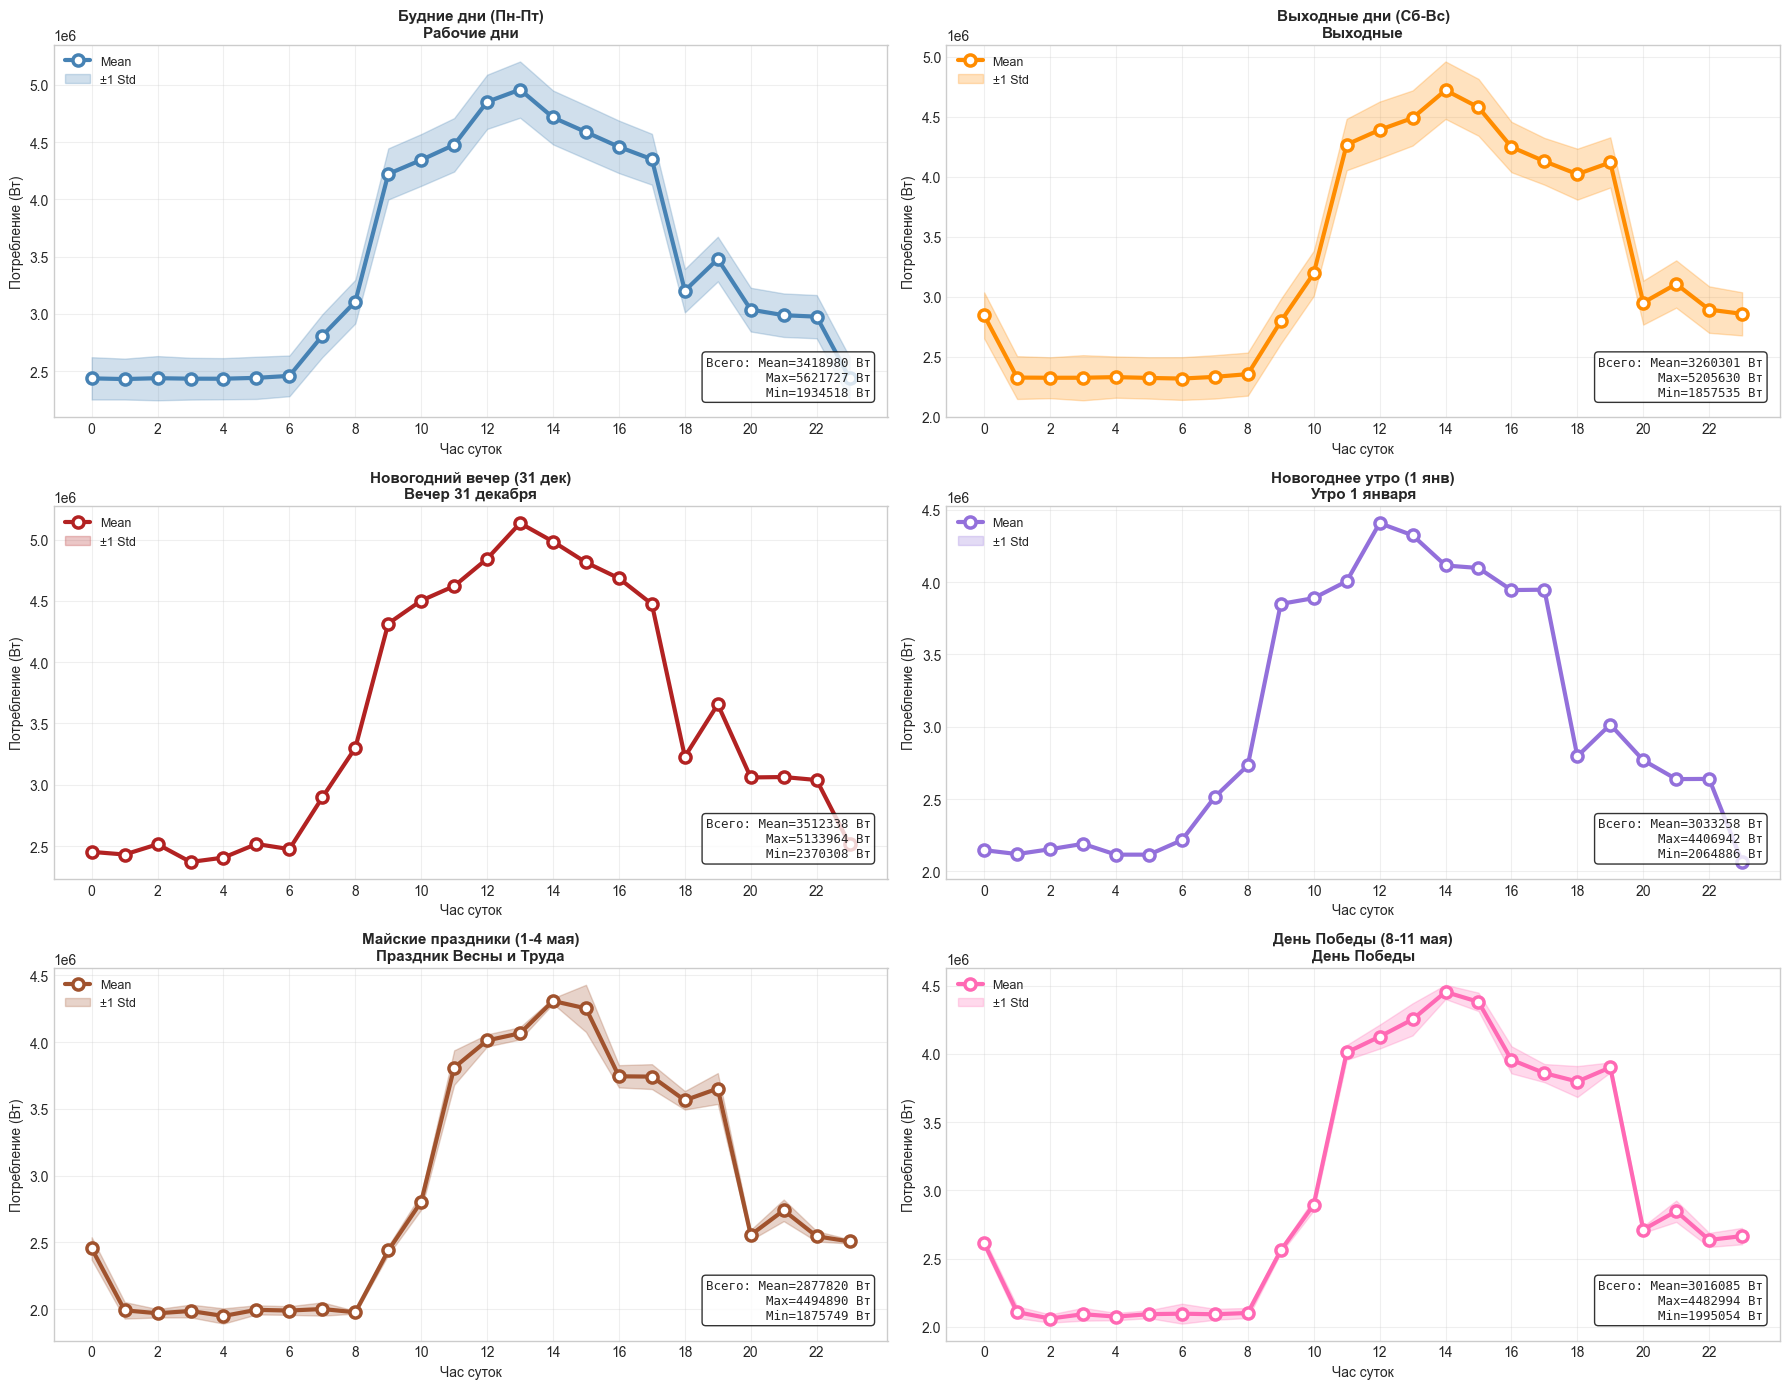

In [7]:

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
axes = axes.flatten()

day_types_detailed = [
    {'type': 'weekday', 'label': 'Будние дни (Пн-Пт)', 'color': 'steelblue', 'description': 'Рабочие дни'},
    {'type': 'weekend', 'label': 'Выходные дни (Сб-Вс)', 'color': 'darkorange', 'description': 'Выходные'},
    {'type': 'new_year_eve', 'label': 'Новогодний вечер (31 дек)', 'color': 'firebrick', 'description': 'Вечер 31 декабря'},
    {'type': 'new_year_morning', 'label': 'Новогоднее утро (1 янв)', 'color': 'mediumpurple', 'description': 'Утро 1 января'},
    {'type': 'may_holiday_1_4', 'label': 'Майские праздники (1-4 мая)', 'color': 'sienna', 'description': 'Праздник Весны и Труда'},
    {'type': 'may_holiday_8_11', 'label': 'День Победы (8-11 мая)', 'color': 'hotpink', 'description': 'День Победы'}
]

for idx, day_type_dict in enumerate(day_types_detailed):
    ax = axes[idx]
    day_type, color = day_type_dict['type'], day_type_dict['color']
    
    stats = df_final[df_final['day_type'] == day_type].groupby('hour')['consumption'].agg(['mean', 'std']).fillna(0)
    
    if stats.empty:
        hourly_vals, hourly_std = np.zeros(24), np.zeros(24)
    else:
        hourly_vals, hourly_std = stats['mean'].values, stats['std'].values
        
    hours = np.arange(24)
    ax.plot(hours, hourly_vals, marker='o', linewidth=3, markersize=8,
           color=color, markerfacecolor='white', markeredgewidth=2.5, label='Mean')
    ax.fill_between(hours, hourly_vals - hourly_std, hourly_vals + hourly_std, alpha=0.25, color=color, label='±1 Std')
    
    ax.set_title(f"{day_type_dict['label']}\n{day_type_dict['description']}", fontsize=11, fontweight='bold')
    ax.set_xlabel('Час суток', fontsize=10)
    ax.set_ylabel('Потребление (Вт)', fontsize=10)
    ax.set_xticks(range(0, 24, 2))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9, loc='upper left')
    
    overall_mean = df_final[df_final['day_type'] == day_type]['consumption'].mean()
    overall_max = df_final[df_final['day_type'] == day_type]['consumption'].max()
    overall_min = df_final[df_final['day_type'] == day_type]['consumption'].min()
    
    if pd.isna(overall_mean): overall_mean = overall_max = overall_min = 0
    
    stats_text = f"Всего: Mean={overall_mean:.0f} Вт\nMax={overall_max:.0f} Вт\nMin={overall_min:.0f} Вт"
    ax.text(0.98, 0.05, stats_text, transform=ax.transAxes, fontsize=9,
           verticalalignment='bottom', horizontalalignment='right',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8), family='monospace')

plt.tight_layout()
plt.savefig('data/03_day_profiles.png', dpi=150, bbox_inches='tight')





# Очистка и сохранение dataframe

In [8]:
if 'hour' in df_final.columns:
    df_final = df_final.drop(columns=['hour'])
if 'weekday' in df_final.columns:
    df_final = df_final.drop(columns=['weekday'])

# Сохраняем сырые данные 
file_path = 'data/raw_data.csv'
df_final.to_csv(file_path, index=False)

print(f" Данные успешно сохранены в {file_path}!")

 Данные успешно сохранены в data/raw_data.csv!
